<div style="padding:34px 36px; border-radius:18px; background:linear-gradient(135deg,#123A63 0%,#176B87 58%,#1FA187 100%); color:white; margin-bottom:22px; box-shadow:0 8px 24px rgba(18,58,99,.18);">
  <div style="font-size:13px; letter-spacing:2px; font-weight:700; opacity:.88;">CUADERNO 1 · PREPARACIÓN DE DATOS</div>
  <h1 style="margin:10px 0 8px 0; font-size:36px; color:white;">Clasificación multilabel de instrumentos quirúrgicos</h1>
  <p style="font-size:18px; margin:0; opacity:.94;">Preparación del dataset y análisis exploratorio</p>
  <div style="margin-top:22px; font-size:15px;"><b>Estudiantes:</b> Madeleine Arévalo, Tatiana Aucapiña y Esteban Tuquiñagui &nbsp;&nbsp;|&nbsp;&nbsp; <b>Año:</b> 2026</div>
</div>

## 1. Definición del problema

### 1.1 Objetivo

Preparar y analizar el conjunto de datos **Labeled Surgical Tools and Images**, desarrollado por Lavado, da Silva y Caramelo (2018), para construir posteriormente una red neuronal capaz de reconocer todos los instrumentos quirúrgicos presentes en una imagen.

Una fotografía puede contener más de un instrumento simultáneamente. Por esta razón, el proyecto se aborda como una tarea de **clasificación multilabel**.

### 1.2 Clases del problema

| Índice | Instrumento | Etiqueta |
|---:|---|:---:|
| 0 | Bisturí n.º 4 | `y0` |
| 1 | Pinza de disección recta | `y1` |
| 2 | Tijera Mayo recta | `y2` |
| 3 | Tijera Mayo curva | `y3` |

### 1.3 Representación multi-hot

Las etiquetas se representan mediante vectores binarios de cuatro posiciones:

- `[1, 0, 0, 0]`: únicamente un bisturí.
- `[1, 0, 1, 0]`: bisturí y tijera Mayo recta.
- `[0, 1, 0, 1]`: pinza de disección recta y tijera Mayo curva.

> Cada posición se interpreta de forma independiente; por ello, varias clases pueden tener el valor `1` en una misma imagen.

### Índice

1. [Definición del problema](#1-definición-del-problema)
2. [Preparación del entorno y descarga](#2-preparación-del-entorno-y-descarga)
3. [Inspección y organización del dataset](#3-inspección-y-organización-del-dataset)
4. [Construcción de etiquetas y particiones](#4-construcción-de-etiquetas-y-particiones)
5. [Análisis exploratorio](#5-análisis-exploratorio)
6. [Exportación de resultados](#6-exportación-de-resultados)
7. [Interpretación y conclusiones](#7-interpretación-y-conclusiones)

---

## 2. Preparación del entorno y descarga

### 2.1 Instalación e importación de librerías

Se instalan y cargan las herramientas necesarias para descargar el dataset, procesar archivos, construir tablas y generar visualizaciones en Google Colab.

In [ ]:
# Instalación de las librerías necesarias en Google Colab
!pip -q install kagglehub iterative-stratification seaborn openpyxl

from pathlib import Path
from collections import Counter
from PIL import Image

import os
import json
import random
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

print("Versión de Python:", platform.python_version())
print("Versión de NumPy:", np.__version__)
print("Versión de pandas:", pd.__version__)
print("Entorno preparado correctamente.")

Versión de Python: 3.12.13
Versión de NumPy: 2.0.2
Versión de pandas: 2.2.2
Entorno preparado correctamente.


### 2.2 Descarga del conjunto de datos

El dataset se obtiene mediante KaggleHub. La ruta resultante se conserva para localizar posteriormente las imágenes, etiquetas YOLO y listas oficiales de entrenamiento y prueba.

In [ ]:
import kagglehub

DATASET_HANDLE = "dilavado/labeled-surgical-tools"

print("Descargando o recuperando el dataset desde Kaggle...")

KAGGLE_PATH = Path(
    kagglehub.dataset_download(DATASET_HANDLE)
)

print("\n✅ Dataset disponible.")
print("Ruta proporcionada por KaggleHub:")
print(KAGGLE_PATH)

print("\n¿Existe la carpeta?:", KAGGLE_PATH.exists())

Descargando o recuperando el dataset desde Kaggle...


100%|██████████| 734M/734M [00:07<00:00, 101MB/s]

Extracting files...



✅ Dataset disponible.
Ruta proporcionada por KaggleHub:
/root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1

¿Existe la carpeta?: True


---

## 3. Inspección y organización del dataset

### 3.1 Inventario de archivos y carpetas

Antes de procesar la información se revisan las extensiones y carpetas disponibles. Esta comprobación permite distinguir imágenes originales, copias, anotaciones y archivos auxiliares.

> **Propósito:** evitar duplicados y seleccionar únicamente la versión correcta de cada imagen.

In [ ]:
# Extensiones utilizadas por las imágenes
IMG_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

# Contar todos los tipos de archivos
conteo_extensiones = Counter()

for archivo in KAGGLE_PATH.rglob("*"):
    if archivo.is_file():
        extension = archivo.suffix.lower()
        conteo_extensiones[extension] += 1

print("=" * 70)
print("TIPOS DE ARCHIVOS ENCONTRADOS")
print("=" * 70)

for extension, cantidad in conteo_extensiones.most_common():
    nombre_extension = extension if extension else "[sin extensión]"
    print(f"{nombre_extension:15} → {cantidad:6} archivos")


# Buscar las carpetas que contienen imágenes
carpetas_con_imagenes = Counter()

for archivo in KAGGLE_PATH.rglob("*"):
    if archivo.is_file() and archivo.suffix.lower() in IMG_EXTENSIONS:
        carpetas_con_imagenes[archivo.parent] += 1

print("\n" + "=" * 70)
print("CARPETAS QUE CONTIENEN IMÁGENES")
print("=" * 70)

for carpeta, cantidad in carpetas_con_imagenes.most_common(30):
    print(f"{cantidad:6} imágenes → {carpeta}")

TIPOS DE ARCHIVOS ENCONTRADOS
.txt            →  12042 archivos
.jpg            →  12036 archivos
.xlsx           →      2 archivos

CARPETAS QUE CONTIENEN IMÁGENES
  3009 imágenes → /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/Surgical-Dataset/Images/All/images
  3009 imágenes → /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/surgical-dataset/Surgical-Dataset/Images/All/images
   550 imágenes → /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/Surgical-Dataset/Images/Curved Mayo Scissor/Alone
   550 imágenes → /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/Surgical-Dataset/Images/Scalpel/Alone
   550 imágenes → /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/surgical-dataset/Surgical-Dataset/Images/Curved Mayo Scissor/Alone
   550 imágenes → /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/surgical-dataset/Surgical-Dataset/I

### 3.2 Definición y verificación de rutas

Se establecen las rutas de imágenes originales, etiquetas YOLO, listas oficiales y carpeta de resultados. También se comprueba que cada ubicación exista antes de continuar.

In [ ]:
# Carpeta principal de la versión que utilizaremos
DATASET_DIR = KAGGLE_PATH / "Surgical-Dataset"

# Imágenes originales, sin duplicados
IMAGE_DIR = (
    DATASET_DIR
    / "Images"
    / "All"
    / "images"
)

# Etiquetas en formato YOLO
LABEL_DIR = (
    DATASET_DIR
    / "Labels"
    / "label object names"
)

# Archivos con la división oficial de entrenamiento y test
SPLIT_DIR = (
    DATASET_DIR
    / "Test-Train Groups"
)

TRAIN_LIST_PATH = (
    SPLIT_DIR
    / "train-obj_detector.txt"
)

TEST_LIST_PATH = (
    SPLIT_DIR
    / "test-obj_detector.txt"
)

# Carpeta donde guardaremos los resultados del Cuaderno 1
PROJECT_DIR = Path(
    "/content/instrumentos_multilabel"
)

ARTIFACTS_DIR = (
    PROJECT_DIR
    / "artifacts"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Obtener imágenes y etiquetas
images = sorted(
    archivo
    for archivo in IMAGE_DIR.iterdir()
    if archivo.suffix.lower() in IMG_EXTENSIONS
)

label_files = sorted(
    LABEL_DIR.glob("*.txt")
)

print("=" * 70)
print("RUTAS SELECCIONADAS")
print("=" * 70)

print("Dataset:", DATASET_DIR)
print("Imágenes:", IMAGE_DIR)
print("Etiquetas:", LABEL_DIR)
print("Lista de entrenamiento:", TRAIN_LIST_PATH)
print("Lista de test:", TEST_LIST_PATH)
print("Resultados:", ARTIFACTS_DIR)

print("\n" + "=" * 70)
print("COMPROBACIÓN")
print("=" * 70)

print("¿Existe la carpeta de imágenes?:", IMAGE_DIR.exists())
print("¿Existe la carpeta de etiquetas?:", LABEL_DIR.exists())
print("¿Existe la lista de entrenamiento?:", TRAIN_LIST_PATH.exists())
print("¿Existe la lista de test?:", TEST_LIST_PATH.exists())

print("\nCantidad de imágenes únicas:", len(images))
print("Cantidad de archivos de etiquetas:", len(label_files))

print("\nPrimeras cinco imágenes:")

for imagen in images[:5]:
    print("•", imagen.name)

RUTAS SELECCIONADAS
Dataset: /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/Surgical-Dataset
Imágenes: /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/Surgical-Dataset/Images/All/images
Etiquetas: /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/Surgical-Dataset/Labels/label object names
Lista de entrenamiento: /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/Surgical-Dataset/Test-Train Groups/train-obj_detector.txt
Lista de test: /root/.cache/kagglehub/datasets/dilavado/labeled-surgical-tools/versions/1/Surgical-Dataset/Test-Train Groups/test-obj_detector.txt
Resultados: /content/instrumentos_multilabel/artifacts

COMPROBACIÓN
¿Existe la carpeta de imágenes?: True
¿Existe la carpeta de etiquetas?: True
¿Existe la lista de entrenamiento?: True
¿Existe la lista de test?: True

Cantidad de imágenes únicas: 3009
Cantidad de archivos de etiquetas: 3009

Primeras cinco imágenes:
• bist

---

## 4. Construcción de etiquetas y particiones

### 4.1 Conversión de anotaciones YOLO a etiquetas multilabel

Las anotaciones de cada imagen se leen para identificar las clases presentes. Posteriormente se transforman en vectores multi-hot compatibles con el entrenamiento de una red neuronal multilabel.

| Anotación original | Representación utilizada |
|---|---|
| Una o varias clases YOLO | Vector binario `[y0, y1, y2, y3]` |

In [ ]:
CLASS_NAMES = [
    "Bisturí n.º 4",
    "Pinza de disección recta",
    "Tijera Mayo recta",
    "Tijera Mayo curva"
]

NUM_CLASSES = len(CLASS_NAMES)

LABEL_COLUMNS = [
    f"y{i}"
    for i in range(NUM_CLASSES)
]


def leer_etiqueta_yolo(label_path):
    """
    Lee un archivo YOLO y devuelve:
    - vector multi-hot de cuatro posiciones;
    - cantidad de objetos anotados;
    - clases encontradas.
    """

    vector_multihot = np.zeros(
        NUM_CLASSES,
        dtype=np.int32
    )

    clases_encontradas = []
    cantidad_objetos = 0

    with open(
        label_path,
        mode="r",
        encoding="utf-8"
    ) as archivo:

        for numero_linea, linea in enumerate(
            archivo,
            start=1
        ):
            linea = linea.strip()

            if not linea:
                continue

            elementos = linea.split()

            if len(elementos) < 5:
                raise ValueError(
                    f"Formato YOLO incorrecto en {label_path.name}, "
                    f"línea {numero_linea}: {linea}"
                )

            clase = int(
                float(elementos[0])
            )

            if clase < 0 or clase >= NUM_CLASSES:
                raise ValueError(
                    f"Clase {clase} fuera del rango 0-{NUM_CLASSES - 1} "
                    f"en {label_path.name}"
                )

            vector_multihot[clase] = 1
            clases_encontradas.append(clase)
            cantidad_objetos += 1

    return (
        vector_multihot,
        cantidad_objetos,
        clases_encontradas
    )


registros = []
errores_lectura = []

for posicion, image_path in enumerate(images, start=1):

    label_path = (
        LABEL_DIR
        / f"{image_path.stem}.txt"
    )

    try:
        if not label_path.exists():
            raise FileNotFoundError(
                f"No existe la etiqueta {label_path.name}"
            )

        vector, cantidad_objetos, clases = leer_etiqueta_yolo(
            label_path
        )

        with Image.open(image_path) as imagen:
            width, height = imagen.size
            image_mode = imagen.mode

        registro = {
            "path": str(image_path),
            "relative_path": image_path.name,
            "label_path": str(label_path),
            "file": image_path.name,
            "width": width,
            "height": height,
            "channels_mode": image_mode,
            "object_count": cantidad_objetos,
            "label_count": int(vector.sum()),
            "class_ids": ",".join(
                map(str, sorted(set(clases)))
            )
        }

        for indice_clase in range(NUM_CLASSES):
            registro[f"y{indice_clase}"] = int(
                vector[indice_clase]
            )

        registros.append(registro)

    except Exception as error:
        errores_lectura.append({
            "imagen": image_path.name,
            "error": str(error)
        })

    if posicion % 500 == 0:
        print(
            f"Procesadas {posicion} de {len(images)} imágenes"
        )


dataset_df = pd.DataFrame(registros)

print("\n" + "=" * 70)
print("RESULTADO DE LA LECTURA")
print("=" * 70)

print("Imágenes procesadas correctamente:", len(dataset_df))
print("Errores encontrados:", len(errores_lectura))

print(
    "Imágenes sin ninguna etiqueta:",
    int(
        (
            dataset_df[LABEL_COLUMNS].sum(axis=1) == 0
        ).sum()
    )
)

print(
    "Imágenes con más de una etiqueta:",
    int(
        (
            dataset_df[LABEL_COLUMNS].sum(axis=1) > 1
        ).sum()
    )
)

print("\nPrimeros registros:")

display(
    dataset_df[
        [
            "file",
            "width",
            "height",
            "channels_mode",
            "object_count",
            "label_count",
            "class_ids"
        ]
        + LABEL_COLUMNS
    ].head(10)
)

if errores_lectura:
    print("\nPrimeros errores:")
    display(
        pd.DataFrame(
            errores_lectura
        ).head(10)
    )

Procesadas 500 de 3009 imágenes
Procesadas 1000 de 3009 imágenes
Procesadas 1500 de 3009 imágenes
Procesadas 2000 de 3009 imágenes
Procesadas 2500 de 3009 imágenes
Procesadas 3000 de 3009 imágenes

RESULTADO DE LA LECTURA
Imágenes procesadas correctamente: 3009
Errores encontrados: 0
Imágenes sin ninguna etiqueta: 0
Imágenes con más de una etiqueta: 999

Primeros registros:


,file,width,height,channels_mode,object_count,label_count,class_ids,y0,y1,y2,y3
0,bisturi1.jpg,640,480,L,1,1,0,1,0,0,0
1,bisturi10.jpg,640,480,L,1,1,0,1,0,0,0
2,bisturi100.jpg,640,480,L,1,1,0,1,0,0,0
3,bisturi101.jpg,640,480,L,1,1,0,1,0,0,0
4,bisturi102.jpg,640,480,L,1,1,0,1,0,0,0
5,bisturi103.jpg,640,480,L,1,1,0,1,0,0,0
6,bisturi104.jpg,640,480,L,1,1,0,1,0,0,0
7,bisturi105.jpg,640,480,L,1,1,0,1,0,0,0
8,bisturi106.jpg,640,480,L,1,1,0,1,0,0,0
9,bisturi107.jpg,640,480,L,1,1,0,1,0,0,0


### 4.2 Lectura de las particiones oficiales

Se recuperan las listas oficiales de entrenamiento y prueba proporcionadas por los autores. Las rutas se normalizan y se comprueba la correspondencia entre cada imagen y su grupo original.

In [ ]:
def leer_lista_oficial(ruta_lista):
    """
    Lee una lista oficial del dataset y devuelve únicamente
    los nombres de los archivos, independientemente de la
    ruta original incluida en el TXT.
    """

    nombres = []

    with open(
        ruta_lista,
        mode="r",
        encoding="utf-8"
    ) as archivo:

        for linea in archivo:
            linea = linea.strip()

            if not linea:
                continue

            # Las rutas originales utilizan Linux.
            nombre_archivo = Path(
                linea.replace("\\", "/")
            ).name

            nombres.append(
                nombre_archivo
            )

    return nombres


train_files_oficial = leer_lista_oficial(
    TRAIN_LIST_PATH
)

test_files_oficial = leer_lista_oficial(
    TEST_LIST_PATH
)

train_set_oficial = set(
    train_files_oficial
)

test_set_oficial = set(
    test_files_oficial
)

dataset_files = set(
    dataset_df["file"]
)


# Comprobaciones
duplicados_train = (
    len(train_files_oficial)
    - len(train_set_oficial)
)

duplicados_test = (
    len(test_files_oficial)
    - len(test_set_oficial)
)

interseccion_train_test = (
    train_set_oficial
    & test_set_oficial
)

faltantes_train = (
    train_set_oficial
    - dataset_files
)

faltantes_test = (
    test_set_oficial
    - dataset_files
)

archivos_oficiales = (
    train_set_oficial
    | test_set_oficial
)

archivos_no_incluidos = (
    dataset_files
    - archivos_oficiales
)


print("=" * 70)
print("DIVISIÓN OFICIAL DEL DATASET")
print("=" * 70)

print(
    "Archivos en entrenamiento oficial:",
    len(train_files_oficial)
)

print(
    "Archivos en test oficial:",
    len(test_files_oficial)
)

print(
    "Total de archivos oficiales:",
    len(archivos_oficiales)
)

print(
    "Archivos no incluidos en la división oficial:",
    len(archivos_no_incluidos)
)

print("\n" + "=" * 70)
print("COMPROBACIONES DE INTEGRIDAD")
print("=" * 70)

print(
    "Duplicados en la lista de entrenamiento:",
    duplicados_train
)

print(
    "Duplicados en la lista de test:",
    duplicados_test
)

print(
    "Imágenes compartidas entre entrenamiento y test:",
    len(interseccion_train_test)
)

print(
    "Imágenes de entrenamiento no encontradas:",
    len(faltantes_train)
)

print(
    "Imágenes de test no encontradas:",
    len(faltantes_test)
)


# Asignar el grupo oficial a cada imagen
dataset_df["split_original"] = np.select(
    [
        dataset_df["file"].isin(train_set_oficial),
        dataset_df["file"].isin(test_set_oficial)
    ],
    [
        "train",
        "test"
    ],
    default="excluded"
)


print("\nDistribución asignada:")

display(
    dataset_df[
        "split_original"
    ].value_counts().rename_axis(
        "Grupo"
    ).to_frame(
        "Cantidad"
    )
)

DIVISIÓN OFICIAL DEL DATASET
Archivos en entrenamiento oficial: 1834
Archivos en test oficial: 786
Total de archivos oficiales: 2620
Archivos no incluidos en la división oficial: 389

COMPROBACIONES DE INTEGRIDAD
Duplicados en la lista de entrenamiento: 0
Duplicados en la lista de test: 0
Imágenes compartidas entre entrenamiento y test: 0
Imágenes de entrenamiento no encontradas: 0
Imágenes de test no encontradas: 0

Distribución asignada:


,Cantidad
Grupo,
train,1834
test,786
excluded,389


### 4.3 División estratificada de entrenamiento y validación

El entrenamiento oficial se divide en entrenamiento y validación considerando las combinaciones multilabel. El conjunto de prueba oficial permanece intacto.

> **Control de calidad:** al finalizar se comprueba que no existan imágenes compartidas entre entrenamiento, validación y prueba.

In [ ]:
from sklearn.model_selection import train_test_split

# Separar los grupos oficiales
train_original_df = dataset_df[
    dataset_df["split_original"] == "train"
].copy().reset_index(drop=True)

test_df = dataset_df[
    dataset_df["split_original"] == "test"
].copy().reset_index(drop=True)

excluded_df = dataset_df[
    dataset_df["split_original"] == "excluded"
].copy().reset_index(drop=True)


# Crear una clave para cada combinación multilabel
train_original_df["label_combination"] = (
    train_original_df[
        LABEL_COLUMNS
    ]
    .astype(str)
    .agg("".join, axis=1)
)


# Contar las combinaciones
frecuencia_combinaciones = (
    train_original_df[
        "label_combination"
    ].value_counts()
)


# Identificar combinaciones con una sola imagen
combinaciones_raras = frecuencia_combinaciones[
    frecuencia_combinaciones < 2
].index.tolist()


print("Combinaciones con una sola imagen:")
print(combinaciones_raras)


# Las combinaciones únicas se conservan en entrenamiento
rare_df = train_original_df[
    train_original_df[
        "label_combination"
    ].isin(combinaciones_raras)
].copy()


# Datos que sí pueden estratificarse
common_df = train_original_df[
    ~train_original_df[
        "label_combination"
    ].isin(combinaciones_raras)
].copy()


print(
    "Imágenes con combinaciones únicas:",
    len(rare_df)
)

print(
    "Imágenes disponibles para estratificación:",
    len(common_df)
)


# Crear exactamente 293 imágenes de validación
common_train_df, val_df = train_test_split(
    common_df,
    test_size=293,
    random_state=SEED,
    shuffle=True,
    stratify=common_df["label_combination"]
)


# Incorporar las combinaciones únicas al entrenamiento
train_df = pd.concat(
    [
        common_train_df,
        rare_df
    ],
    ignore_index=True
)


# Mezclar el entrenamiento de forma reproducible
train_df = train_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
excluded_df = excluded_df.reset_index(drop=True)


# Eliminar la columna auxiliar
train_df = train_df.drop(
    columns=["label_combination"]
)

val_df = val_df.drop(
    columns=["label_combination"]
)


# Asignar particiones definitivas
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"
excluded_df["split"] = "excluded"


print("\n" + "=" * 70)
print("DIVISIÓN DEFINITIVA")
print("=" * 70)

print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))
print("Excluidas:", len(excluded_df))

print(
    "\nTotal utilizado:",
    len(train_df) + len(val_df) + len(test_df)
)


# Comprobar fuga de datos
train_names = set(train_df["file"])
val_names = set(val_df["file"])
test_names = set(test_df["file"])

print("\n" + "=" * 70)
print("COMPROBACIÓN DE FUGA DE DATOS")
print("=" * 70)

print(
    "Coincidencias train-validación:",
    len(train_names & val_names)
)

print(
    "Coincidencias train-test:",
    len(train_names & test_names)
)

print(
    "Coincidencias validación-test:",
    len(val_names & test_names)
)


# Frecuencias por clase
frecuencias_particiones = pd.DataFrame(
    {
        "Entrenamiento": train_df[
            LABEL_COLUMNS
        ].sum().to_numpy(),

        "Validación": val_df[
            LABEL_COLUMNS
        ].sum().to_numpy(),

        "Test": test_df[
            LABEL_COLUMNS
        ].sum().to_numpy()
    },
    index=CLASS_NAMES
)

frecuencias_particiones.index.name = "Instrumento"

print("\nFrecuencia de etiquetas por partición:")

display(
    frecuencias_particiones
)


# Porcentajes de presencia por partición
porcentajes_particiones = pd.DataFrame(
    {
        "Entrenamiento (%)": (
            train_df[LABEL_COLUMNS].mean().to_numpy()
            * 100
        ),

        "Validación (%)": (
            val_df[LABEL_COLUMNS].mean().to_numpy()
            * 100
        ),

        "Test (%)": (
            test_df[LABEL_COLUMNS].mean().to_numpy()
            * 100
        )
    },
    index=CLASS_NAMES
).round(2)

porcentajes_particiones.index.name = "Instrumento"

print("\nPorcentaje de imágenes que contienen cada instrumento:")

display(
    porcentajes_particiones
)

Combinaciones con una sola imagen:
['0111']
Imágenes con combinaciones únicas: 1
Imágenes disponibles para estratificación: 1833

DIVISIÓN DEFINITIVA
Entrenamiento: 1541
Validación: 293
Test: 786
Excluidas: 389

Total utilizado: 2620

COMPROBACIÓN DE FUGA DE DATOS
Coincidencias train-validación: 0
Coincidencias train-test: 0
Coincidencias validación-test: 0

Frecuencia de etiquetas por partición:


,Entrenamiento,Validación,Test
Instrumento,,,
Bisturí n.º 4,536,101,273
Pinza de disección recta,535,102,273
Tijera Mayo recta,535,102,272
Tijera Mayo curva,535,102,274



Porcentaje de imágenes que contienen cada instrumento:


,Entrenamiento (%),Validación (%),Test (%)
Instrumento,,,
Bisturí n.º 4,34.78,34.47,34.73
Pinza de disección recta,34.72,34.81,34.73
Tijera Mayo recta,34.72,34.81,34.61
Tijera Mayo curva,34.72,34.81,34.86


---

## 5. Análisis exploratorio

### 5.1 Resumen general del dataset

Se calculan el número de imágenes por partición, la cantidad de ejemplos con una o varias etiquetas y el promedio de etiquetas por imagen.

In [ ]:
# Unir únicamente las particiones que se utilizarán
used_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)


# Cantidad de etiquetas positivas
total_etiquetas = int(
    used_df[
        LABEL_COLUMNS
    ].to_numpy().sum()
)


# Imágenes multilabel
cantidad_multilabel = int(
    (
        used_df[
            LABEL_COLUMNS
        ].sum(axis=1) > 1
    ).sum()
)


# Imágenes con una sola etiqueta
cantidad_single_label = int(
    (
        used_df[
            LABEL_COLUMNS
        ].sum(axis=1) == 1
    ).sum()
)


# Promedio de etiquetas por imagen
promedio_etiquetas = float(
    used_df[
        LABEL_COLUMNS
    ].sum(axis=1).mean()
)


# Resumen ejecutivo
resumen_dataset = pd.DataFrame({
    "Característica": [
        "Imágenes únicas disponibles",
        "Imágenes utilizadas oficialmente",
        "Imágenes de entrenamiento",
        "Imágenes de validación",
        "Imágenes de test",
        "Imágenes excluidas por la división oficial",
        "Ancho predominante",
        "Alto predominante",
        "Modo de color predominante",
        "Número de clases",
        "Total de etiquetas positivas",
        "Imágenes con una sola etiqueta",
        "Imágenes multilabel",
        "Promedio de etiquetas por imagen"
    ],

    "Resultado": [
        len(dataset_df),
        len(used_df),
        len(train_df),
        len(val_df),
        len(test_df),
        len(excluded_df),
        int(used_df["width"].mode()[0]),
        int(used_df["height"].mode()[0]),
        used_df["channels_mode"].mode()[0],
        NUM_CLASSES,
        total_etiquetas,
        cantidad_single_label,
        cantidad_multilabel,
        round(promedio_etiquetas, 4)
    ]
})


print("=" * 70)
print("RESUMEN DEL DATASET UTILIZADO")
print("=" * 70)

display(
    resumen_dataset
)


print("\n" + "=" * 70)
print("DIMENSIONES DE LAS IMÁGENES")
print("=" * 70)

dimensiones_df = (
    used_df
    .groupby(
        [
            "width",
            "height",
            "channels_mode"
        ]
    )
    .size()
    .reset_index(
        name="Cantidad"
    )
    .sort_values(
        "Cantidad",
        ascending=False
    )
)

display(
    dimensiones_df
)


print("\n" + "=" * 70)
print("FRECUENCIA TOTAL DE LAS ETIQUETAS")
print("=" * 70)

frecuencia_total = pd.DataFrame({
    "Instrumento": CLASS_NAMES,
    "Frecuencia": (
        used_df[
            LABEL_COLUMNS
        ].sum().to_numpy()
    )
})

frecuencia_total["Porcentaje de imágenes"] = (
    frecuencia_total["Frecuencia"]
    / len(used_df)
    * 100
).round(2)

display(
    frecuencia_total
)

RESUMEN DEL DATASET UTILIZADO


,Característica,Resultado
0,Imágenes únicas disponibles,3009
1,Imágenes utilizadas oficialmente,2620
2,Imágenes de entrenamiento,1541
3,Imágenes de validación,293
4,Imágenes de test,786
5,Imágenes excluidas por la división oficial,389
6,Ancho predominante,640
7,Alto predominante,480
8,Modo de color predominante,L
9,Número de clases,4



DIMENSIONES DE LAS IMÁGENES


,width,height,channels_mode,Cantidad
0,640,480,L,2620



FRECUENCIA TOTAL DE LAS ETIQUETAS


,Instrumento,Frecuencia,Porcentaje de imágenes
0,Bisturí n.º 4,910,34.73
1,Pinza de disección recta,910,34.73
2,Tijera Mayo recta,909,34.69
3,Tijera Mayo curva,911,34.77


### 5.2 Visualización de imágenes representativas

Se muestran ejemplos con una sola clase y ejemplos multilabel. Esta revisión visual permite comprobar que las imágenes y sus etiquetas coincidan correctamente.

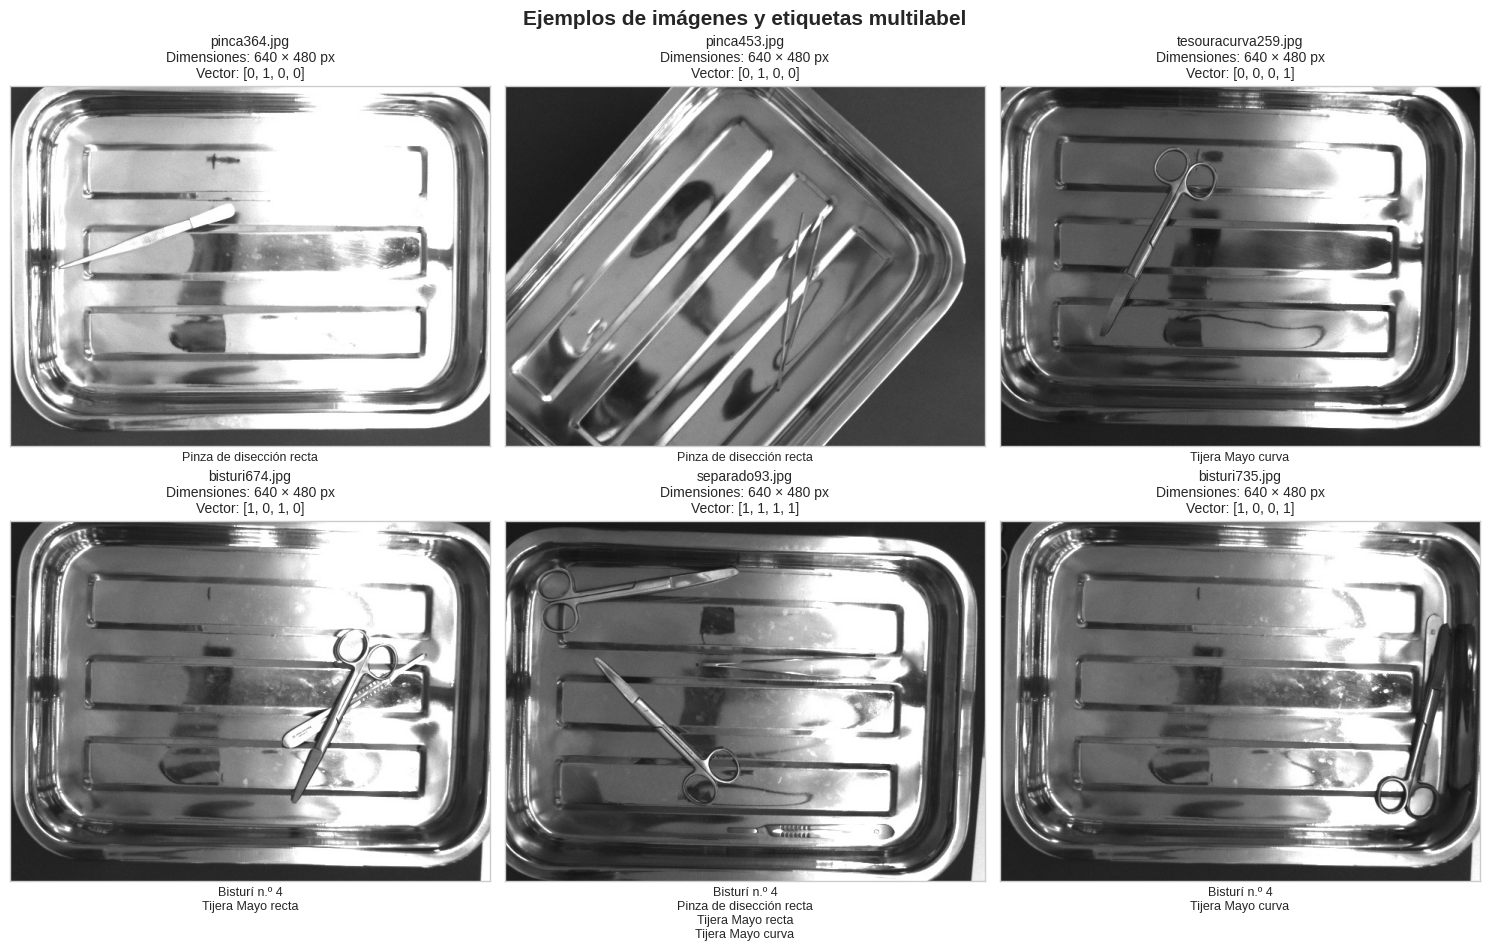

In [ ]:
def obtener_nombres_etiquetas(fila):
    """
    Convierte el vector multi-hot de una fila
    en los nombres de los instrumentos.
    """

    etiquetas = []

    for indice, nombre_clase in enumerate(CLASS_NAMES):
        if int(fila[f"y{indice}"]) == 1:
            etiquetas.append(nombre_clase)

    return etiquetas


def visualizar_imagenes(
    datos,
    indices=None,
    cantidad=6,
    seed=SEED
):
    """
    Visualiza una o varias imágenes junto con:
    - nombre del archivo;
    - dimensiones;
    - etiquetas reales;
    - vector multi-hot.
    """

    if indices is None:
        cantidad = min(
            cantidad,
            len(datos)
        )

        muestra = datos.sample(
            n=cantidad,
            random_state=seed
        )

    else:
        muestra = datos.loc[
            indices
        ].copy()

    cantidad_imagenes = len(muestra)

    columnas = min(
        3,
        cantidad_imagenes
    )

    filas = int(
        np.ceil(
            cantidad_imagenes
            / columnas
        )
    )

    fig, axes = plt.subplots(
        filas,
        columnas,
        figsize=(
            5 * columnas,
            4.8 * filas
        )
    )

    axes = np.array(
        axes
    ).reshape(-1)

    for eje, (_, fila_datos) in zip(
        axes,
        muestra.iterrows()
    ):

        ruta_imagen = Path(
            fila_datos["path"]
        )

        with Image.open(ruta_imagen) as imagen:
            imagen_mostrar = imagen.convert("RGB")

        etiquetas = obtener_nombres_etiquetas(
            fila_datos
        )

        vector_multihot = [
            int(fila_datos[columna])
            for columna in LABEL_COLUMNS
        ]

        eje.imshow(
            imagen_mostrar
        )

        eje.set_title(
            f"{fila_datos['file']}\n"
            f"Dimensiones: {fila_datos['width']} × "
            f"{fila_datos['height']} px\n"
            f"Vector: {vector_multihot}",
            fontsize=10
        )

        eje.set_xlabel(
            "\n".join(etiquetas),
            fontsize=9
        )

        eje.set_xticks([])
        eje.set_yticks([])

    # Ocultar ejes sobrantes
    for eje in axes[cantidad_imagenes:]:
        eje.axis("off")

    plt.suptitle(
        "Ejemplos de imágenes y etiquetas multilabel",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# Seleccionar tres imágenes de una etiqueta
single_label_sample = used_df[
    used_df["label_count"] == 1
].sample(
    n=3,
    random_state=SEED
)


# Seleccionar tres imágenes multilabel
multilabel_sample = used_df[
    used_df["label_count"] > 1
].sample(
    n=3,
    random_state=SEED
)


# Combinar ambas muestras
muestra_visualizacion = pd.concat(
    [
        single_label_sample,
        multilabel_sample
    ]
)


# Mostrar las imágenes
visualizar_imagenes(
    muestra_visualizacion,
    indices=muestra_visualizacion.index.tolist()
)

### 5.3 Distribución de las clases

Las frecuencias totales y por partición permiten verificar el equilibrio entre las cuatro clases y detectar posibles diferencias entre entrenamiento, validación y prueba.

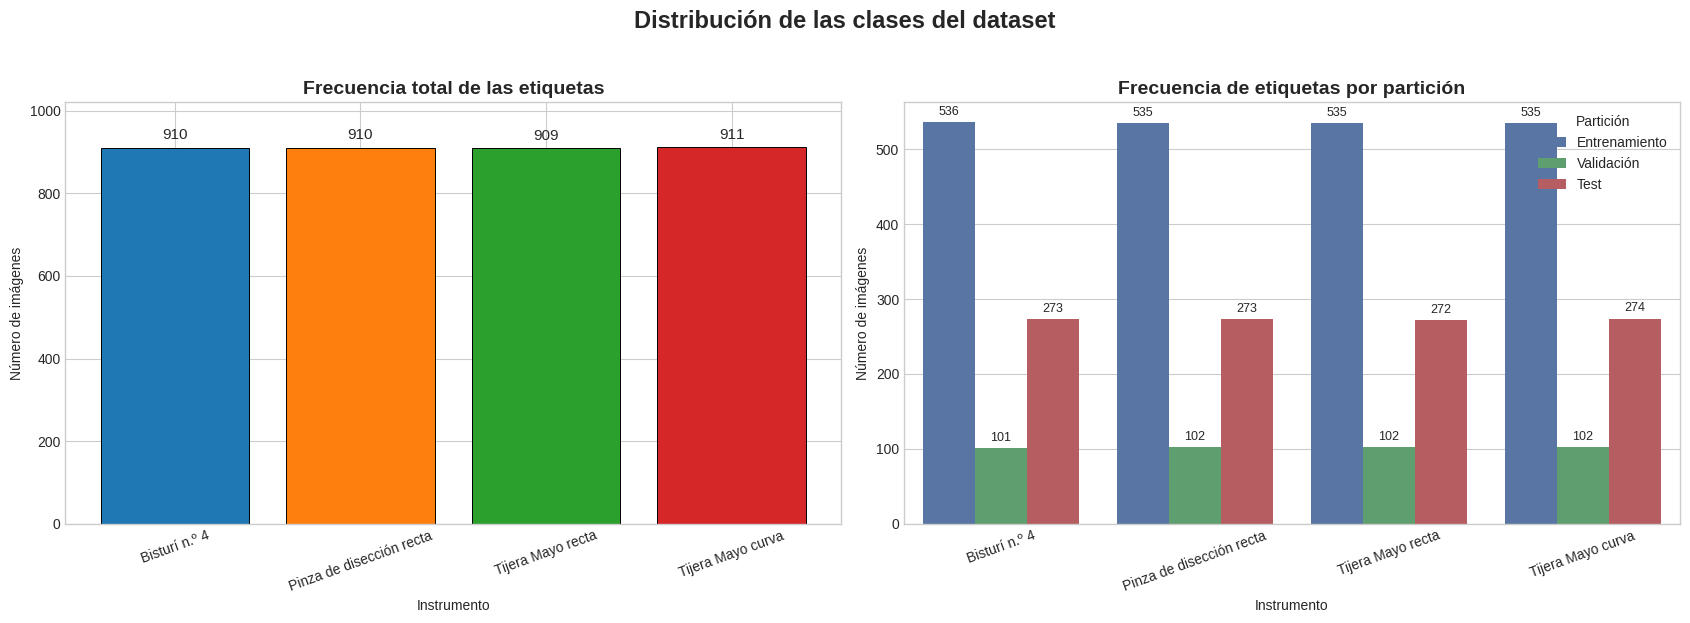

Figura guardada en: /content/instrumentos_multilabel/artifacts/frecuencia_etiquetas.png


In [ ]:
# Preparar frecuencias totales
frecuencia_total = pd.DataFrame({
    "Instrumento": CLASS_NAMES,
    "Frecuencia": (
        used_df[
            LABEL_COLUMNS
        ].sum().to_numpy()
    )
})


# Preparar frecuencias por partición
frecuencia_por_split = pd.DataFrame({
    "Instrumento": CLASS_NAMES,
    "Entrenamiento": (
        train_df[
            LABEL_COLUMNS
        ].sum().to_numpy()
    ),
    "Validación": (
        val_df[
            LABEL_COLUMNS
        ].sum().to_numpy()
    ),
    "Test": (
        test_df[
            LABEL_COLUMNS
        ].sum().to_numpy()
    )
})


frecuencia_larga = frecuencia_por_split.melt(
    id_vars="Instrumento",
    var_name="Partición",
    value_name="Frecuencia"
)


# Crear la figura
fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 6)
)


# Gráfica 1: frecuencia total
colores_clases = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728"
]

barras = axes[0].bar(
    frecuencia_total["Instrumento"],
    frecuencia_total["Frecuencia"],
    color=colores_clases,
    edgecolor="black",
    linewidth=0.7
)

axes[0].set_title(
    "Frecuencia total de las etiquetas",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Instrumento"
)

axes[0].set_ylabel(
    "Número de imágenes"
)

axes[0].tick_params(
    axis="x",
    rotation=20
)

axes[0].set_ylim(
    0,
    frecuencia_total["Frecuencia"].max() * 1.12
)

axes[0].bar_label(
    barras,
    padding=4,
    fontsize=11
)


# Gráfica 2: frecuencia por partición
sns.barplot(
    data=frecuencia_larga,
    x="Instrumento",
    y="Frecuencia",
    hue="Partición",
    ax=axes[1],
    palette={
        "Entrenamiento": "#4C72B0",
        "Validación": "#55A868",
        "Test": "#C44E52"
    }
)

axes[1].set_title(
    "Frecuencia de etiquetas por partición",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Instrumento"
)

axes[1].set_ylabel(
    "Número de imágenes"
)

axes[1].tick_params(
    axis="x",
    rotation=20
)

axes[1].legend(
    title="Partición"
)


# Agregar valores sobre las barras
for contenedor in axes[1].containers:
    axes[1].bar_label(
        contenedor,
        padding=3,
        fontsize=9
    )


plt.suptitle(
    "Distribución de las clases del dataset",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

# Guardar la figura para la presentación
FRECUENCIA_FIG_PATH = (
    ARTIFACTS_DIR
    / "frecuencia_etiquetas.png"
)

plt.savefig(
    FRECUENCIA_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figura guardada en:",
    FRECUENCIA_FIG_PATH
)

### 5.4 Cardinalidad y coocurrencia de etiquetas

La cardinalidad indica cuántos instrumentos diferentes aparecen en cada imagen. La matriz de coocurrencia muestra con qué frecuencia aparecen simultáneamente dos clases.

> Estas visualizaciones confirman cuantitativamente la naturaleza multilabel del problema.

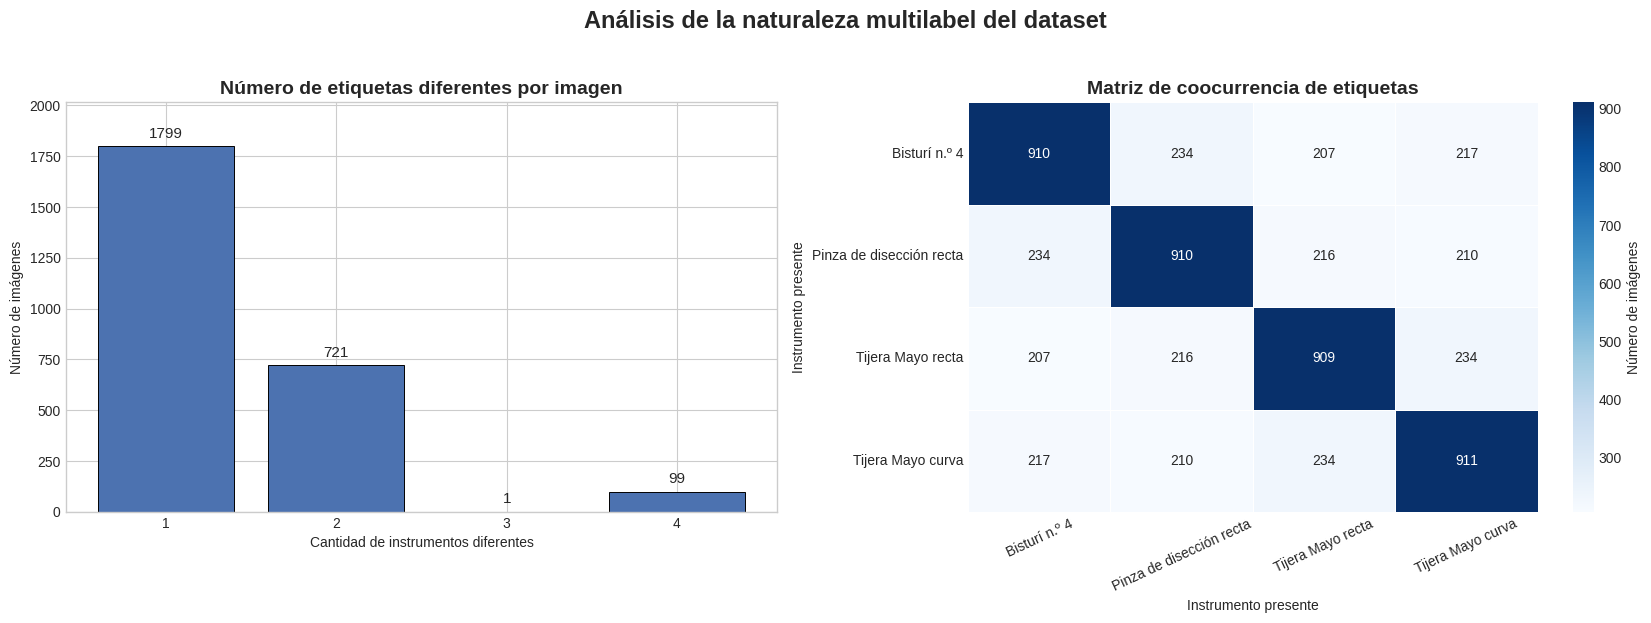

Distribución del número de etiquetas:


,Cantidad de imágenes
Número de etiquetas,
1,1799
2,721
3,1
4,99



Matriz de coocurrencia:


,Bisturí n.º 4,Pinza de disección recta,Tijera Mayo recta,Tijera Mayo curva
Bisturí n.º 4,910,234,207,217
Pinza de disección recta,234,910,216,210
Tijera Mayo recta,207,216,909,234
Tijera Mayo curva,217,210,234,911



Figura guardada en: /content/instrumentos_multilabel/artifacts/cardinalidad_y_coocurrencia.png


In [ ]:
# Número de etiquetas diferentes presentes en cada imagen
cardinalidad = (
    used_df[
        LABEL_COLUMNS
    ].sum(axis=1)
)


frecuencia_cardinalidad = (
    cardinalidad
    .value_counts()
    .sort_index()
)


# Matriz de etiquetas
Y_USED = used_df[
    LABEL_COLUMNS
].to_numpy(
    dtype=np.int32
)


# Matriz de coocurrencia
matriz_coocurrencia = pd.DataFrame(
    Y_USED.T @ Y_USED,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


# Crear figura
fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 6)
)


# Gráfica de cardinalidad
barras = axes[0].bar(
    frecuencia_cardinalidad.index.astype(str),
    frecuencia_cardinalidad.values,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.7
)

axes[0].set_title(
    "Número de etiquetas diferentes por imagen",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Cantidad de instrumentos diferentes"
)

axes[0].set_ylabel(
    "Número de imágenes"
)

axes[0].bar_label(
    barras,
    padding=4,
    fontsize=11
)

axes[0].set_ylim(
    0,
    frecuencia_cardinalidad.max() * 1.12
)


# Mapa de calor de coocurrencia
sns.heatmap(
    matriz_coocurrencia,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Número de imágenes"
    },
    ax=axes[1]
)

axes[1].set_title(
    "Matriz de coocurrencia de etiquetas",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Instrumento presente"
)

axes[1].set_ylabel(
    "Instrumento presente"
)

axes[1].tick_params(
    axis="x",
    rotation=25
)

axes[1].tick_params(
    axis="y",
    rotation=0
)


plt.suptitle(
    "Análisis de la naturaleza multilabel del dataset",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()


COOCURRENCIA_FIG_PATH = (
    ARTIFACTS_DIR
    / "cardinalidad_y_coocurrencia.png"
)

plt.savefig(
    COOCURRENCIA_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Distribución del número de etiquetas:")

display(
    frecuencia_cardinalidad.rename_axis(
        "Número de etiquetas"
    ).to_frame(
        "Cantidad de imágenes"
    )
)


print("\nMatriz de coocurrencia:")

display(
    matriz_coocurrencia
)


print(
    "\nFigura guardada en:",
    COOCURRENCIA_FIG_PATH
)

---

## 6. Exportación de resultados

### 6.1 Archivos de configuración y particiones

Se guardan los `DataFrame` de entrenamiento, validación y prueba, junto con la configuración necesaria para que el Cuaderno 2 pueda reconstruir el flujo de entrenamiento.

**Archivos principales:** `train.csv`, `val.csv`, `test.csv`, dataset consolidado y configuración de clases.

In [ ]:
# Seleccionar columnas que se guardarán
COLUMNAS_SALIDA = [
    "path",
    "relative_path",
    "label_path",
    "file",
    "width",
    "height",
    "channels_mode",
    "object_count",
    "label_count",
    "class_ids"
] + LABEL_COLUMNS + [
    "split_original",
    "split"
]


# Dataset completo utilizado
dataset_utilizado_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)


# Rutas de salida
TRAIN_CSV_PATH = (
    ARTIFACTS_DIR
    / "train.csv"
)

VAL_CSV_PATH = (
    ARTIFACTS_DIR
    / "val.csv"
)

TEST_CSV_PATH = (
    ARTIFACTS_DIR
    / "test.csv"
)

DATASET_CSV_PATH = (
    ARTIFACTS_DIR
    / "dataset_utilizado.csv"
)

EXCLUDED_CSV_PATH = (
    ARTIFACTS_DIR
    / "dataset_excluido.csv"
)

CONFIG_JSON_PATH = (
    ARTIFACTS_DIR
    / "config.json"
)

SUMMARY_CSV_PATH = (
    ARTIFACTS_DIR
    / "resumen_dataset.csv"
)

FREQUENCY_CSV_PATH = (
    ARTIFACTS_DIR
    / "frecuencia_etiquetas.csv"
)

COOCCURRENCE_CSV_PATH = (
    ARTIFACTS_DIR
    / "matriz_coocurrencia.csv"
)


# Guardar archivos CSV
train_df[
    COLUMNAS_SALIDA
].to_csv(
    TRAIN_CSV_PATH,
    index=False
)

val_df[
    COLUMNAS_SALIDA
].to_csv(
    VAL_CSV_PATH,
    index=False
)

test_df[
    COLUMNAS_SALIDA
].to_csv(
    TEST_CSV_PATH,
    index=False
)

dataset_utilizado_df[
    COLUMNAS_SALIDA
].to_csv(
    DATASET_CSV_PATH,
    index=False
)

excluded_df[
    COLUMNAS_SALIDA
].to_csv(
    EXCLUDED_CSV_PATH,
    index=False
)

resumen_dataset.to_csv(
    SUMMARY_CSV_PATH,
    index=False
)

frecuencia_total.to_csv(
    FREQUENCY_CSV_PATH,
    index=False
)

matriz_coocurrencia.to_csv(
    COOCCURRENCE_CSV_PATH
)


# Configuración necesaria para los siguientes cuadernos
configuracion = {
    "dataset_handle": DATASET_HANDLE,
    "dataset_version": 1,
    "class_names": CLASS_NAMES,
    "label_columns": LABEL_COLUMNS,
    "num_classes": NUM_CLASSES,
    "original_image_width": 640,
    "original_image_height": 480,
    "original_image_mode": "L",
    "model_image_size": [
        224,
        224
    ],
    "seed": SEED,
    "total_unique_images": int(
        len(dataset_df)
    ),
    "official_images_used": int(
        len(dataset_utilizado_df)
    ),
    "train_images": int(
        len(train_df)
    ),
    "validation_images": int(
        len(val_df)
    ),
    "test_images": int(
        len(test_df)
    ),
    "excluded_images": int(
        len(excluded_df)
    ),
    "multilabel_images": int(
        (
            dataset_utilizado_df[
                LABEL_COLUMNS
            ].sum(axis=1) > 1
        ).sum()
    ),
    "average_labels_per_image": float(
        dataset_utilizado_df[
            LABEL_COLUMNS
        ].sum(axis=1).mean()
    )
}


with open(
    CONFIG_JSON_PATH,
    mode="w",
    encoding="utf-8"
) as archivo_json:

    json.dump(
        configuracion,
        archivo_json,
        ensure_ascii=False,
        indent=4
    )


print("=" * 70)
print("ARCHIVOS GUARDADOS")
print("=" * 70)

archivos_guardados = [
    TRAIN_CSV_PATH,
    VAL_CSV_PATH,
    TEST_CSV_PATH,
    DATASET_CSV_PATH,
    EXCLUDED_CSV_PATH,
    CONFIG_JSON_PATH,
    SUMMARY_CSV_PATH,
    FREQUENCY_CSV_PATH,
    COOCCURRENCE_CSV_PATH,
    FRECUENCIA_FIG_PATH,
    COOCURRENCIA_FIG_PATH
]

for archivo in archivos_guardados:
    if archivo.exists():
        tamaño_kb = archivo.stat().st_size / 1024

        print(
            f"✅ {archivo.name:35} "
            f"{tamaño_kb:10.2f} KB"
        )
    else:
        print(
            f"❌ No se creó: {archivo.name}"
        )


print("\n" + "=" * 70)
print("COMPROBACIÓN DE LOS CSV")
print("=" * 70)

print(
    "Filas de train.csv:",
    len(
        pd.read_csv(TRAIN_CSV_PATH)
    )
)

print(
    "Filas de val.csv:",
    len(
        pd.read_csv(VAL_CSV_PATH)
    )
)

print(
    "Filas de test.csv:",
    len(
        pd.read_csv(TEST_CSV_PATH)
    )
)

print(
    "Filas de dataset_utilizado.csv:",
    len(
        pd.read_csv(DATASET_CSV_PATH)
    )
)

ARCHIVOS GUARDADOS
✅ train.csv                               498.95 KB
✅ val.csv                                  94.40 KB
✅ test.csv                                253.14 KB
✅ dataset_utilizado.csv                   846.24 KB
✅ dataset_excluido.csv                    129.81 KB
✅ config.json                               0.75 KB
✅ resumen_dataset.csv                       0.45 KB
✅ frecuencia_etiquetas.csv                  0.11 KB
✅ matriz_coocurrencia.csv                   0.22 KB
✅ frecuencia_etiquetas.png                251.92 KB
✅ cardinalidad_y_coocurrencia.png         348.14 KB

COMPROBACIÓN DE LOS CSV
Filas de train.csv: 1541
Filas de val.csv: 293
Filas de test.csv: 786
Filas de dataset_utilizado.csv: 2620


### 6.2 Empaquetado y descarga

Los resultados del Cuaderno 1 se agrupan en un archivo ZIP para facilitar su conservación y carga en el Cuaderno 2.

> Guarda este paquete junto con el cuaderno: contiene las particiones y configuraciones necesarias para continuar el proyecto.

In [ ]:
import zipfile

ZIP_CUADERNO_1 = (
    PROJECT_DIR
    / "resultados_cuaderno_1.zip"
)


# Eliminar una versión anterior si existe
if ZIP_CUADERNO_1.exists():
    ZIP_CUADERNO_1.unlink()


# Crear el archivo ZIP
with zipfile.ZipFile(
    ZIP_CUADERNO_1,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as archivo_zip:

    for archivo in sorted(
        ARTIFACTS_DIR.iterdir()
    ):
        if archivo.is_file():
            archivo_zip.write(
                archivo,
                arcname=archivo.name
            )


print("=" * 70)
print("PAQUETE DEL CUADERNO 1")
print("=" * 70)

print(
    "Ruta:",
    ZIP_CUADERNO_1
)

print(
    "Tamaño:",
    f"{ZIP_CUADERNO_1.stat().st_size / 1024:.2f} KB"
)


print("\nContenido:")

with zipfile.ZipFile(
    ZIP_CUADERNO_1,
    mode="r"
) as archivo_zip:

    for nombre in archivo_zip.namelist():
        print("•", nombre)


# Descargar desde Google Colab
from google.colab import files

print("\nIniciando descarga...")

files.download(
    str(ZIP_CUADERNO_1)
)

PAQUETE DEL CUADERNO 1
Ruta: /content/instrumentos_multilabel/resultados_cuaderno_1.zip
Tamaño: 560.32 KB

Contenido:
• cardinalidad_y_coocurrencia.png
• config.json
• dataset_excluido.csv
• dataset_utilizado.csv
• frecuencia_etiquetas.csv
• frecuencia_etiquetas.png
• matriz_coocurrencia.csv
• resumen_dataset.csv
• test.csv
• train.csv
• val.csv

Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## 7. Interpretación y conclusiones

### 7.1 Interpretación del análisis exploratorio

El conjunto de datos descargado contiene **3,009 imágenes únicas**. Sin embargo, los autores proporcionan una división oficial formada por **1,834 imágenes de entrenamiento** y **786 imágenes de prueba**, para un total de **2,620 imágenes utilizadas**. Las 389 imágenes restantes no se incorporaron al entrenamiento ni a la evaluación con el propósito de respetar la partición original del dataset.

Las 1,834 imágenes del entrenamiento oficial se dividieron en **1,541 imágenes de entrenamiento** y **293 imágenes de validación**. La separación se realizó de forma estratificada según las combinaciones multilabel, mientras que las 786 imágenes del conjunto de prueba permanecieron sin modificaciones. Las comprobaciones realizadas demostraron que no existen imágenes compartidas entre entrenamiento, validación y prueba.

Todas las imágenes presentan una resolución de **640 × 480 píxeles** y se encuentran almacenadas originalmente en escala de grises. Para el modelo de transferencia de aprendizaje se convertirán posteriormente a tres canales RGB y se redimensionarán a **224 × 224 píxeles**.

#### Distribución de las clases

| Instrumento | Frecuencia |
|---|---:|
| Bisturí n.º 4 | 910 |
| Pinza de disección recta | 910 |
| Tijera Mayo recta | 909 |
| Tijera Mayo curva | 911 |

Las frecuencias son prácticamente iguales; por tanto, el conjunto está equilibrado y no requiere técnicas adicionales de sobremuestreo o submuestreo.

#### Naturaleza multilabel

De las 2,620 imágenes utilizadas, **1,799 contienen una sola clase** y **821 contienen más de una clase**. Específicamente, 721 imágenes contienen dos clases, una imagen contiene tres clases y 99 imágenes contienen las cuatro clases. El promedio fue de **1.3893 etiquetas por imagen**.

La matriz de coocurrencia mostró que todas las parejas de instrumentos aparecen simultáneamente en múltiples imágenes. Las coocurrencias se encuentran entre 207 y 234 imágenes por pareja, lo que demuestra que el modelo deberá aprender a identificar varias clases de manera independiente dentro de una misma imagen.

### 7.2 Conclusiones del Cuaderno 1

- Se identificaron correctamente las imágenes originales del dataset y se evitaron las copias duplicadas incluidas en otras carpetas.
- Las anotaciones YOLO se transformaron correctamente en vectores multi-hot de cuatro posiciones.
- No se encontraron imágenes sin etiquetas ni archivos con errores de lectura.
- Se respetó el conjunto de prueba oficial de 786 imágenes.
- Se construyeron conjuntos de entrenamiento, validación y prueba sin fuga de datos.
- Las cuatro clases presentan una distribución equilibrada.
- La presencia de 821 imágenes con más de una etiqueta confirma que el problema debe resolverse mediante clasificación multilabel.
- Los archivos generados permiten continuar con el entrenamiento de una CNN con transferencia de aprendizaje en el Cuaderno 2.

### 7.3 Relevancia clínica

En el entorno quirúrgico, la identificación y organización del instrumental constituye una actividad importante para la seguridad del paciente. Los instrumentos retenidos accidentalmente se consideran eventos que deberían evitarse mediante procedimientos adecuados de conteo y verificación. Un sistema de reconocimiento automático podría funcionar como herramienta complementaria para apoyar al personal sanitario; sin embargo, no debe reemplazar los protocolos institucionales ni la verificación realizada por profesionales.

### 7.4 Referencias

Gawande, A. A., Studdert, D. M., Orav, E. J., Brennan, T. A., & Zinner, M. J. (2003). Risk factors for retained instruments and sponges after surgery. *New England Journal of Medicine, 348*(3), 229–235. https://doi.org/10.1056/NEJMsa021721

Hariharan, D., & Lobo, D. N. (2013). Retained surgical sponges, needles and instruments. *Annals of the Royal College of Surgeons of England, 95*(2), 87–92. https://doi.org/10.1308/003588413X13511609957218

Lavado, D., da Silva, J., & Caramelo, F. (2018). *Labeled Surgical Tools and Images* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/dilavado/labeled-surgical-tools

Organización Mundial de la Salud. (2009). *WHO guidelines for safe surgery 2009: Safe surgery saves lives*. World Health Organization. https://iris.who.int/handle/10665/44185

<div style="padding:18px 22px; border-left:5px solid #1FA187; background:#F2FAF8; border-radius:8px; margin-top:22px;">
  <b>Continuidad del proyecto</b><br>
  El archivo ZIP generado en este cuaderno contiene la información necesaria para desarrollar el entrenamiento y la optimización del modelo en el Cuaderno 2.
</div>